# **Análise Estatística do Mercado Global de Videogames: Fatores Determinantes do Sucesso Comercial**

## *Investigando a correlação entre avaliações críticas e desempenho de vendas dos principais títulos do mercado*

---

**Autores:** Wagner Victor Alves de Menezes, Victor Gabriel Ribeiro Jacome

**Instituição:** Universidade Federal de Goiás - Instituto de Matemática e Estatística

**Disciplina:** Probabilidade e Estatística A

**Professora:** Amanda B. G. Milani

**Data:** 25/11/2025

---

## **Resumo**

A indústria de videogames representa um dos mercados de entretenimento mais lucrativos globalmente, movimentando mais de 180 bilhões de dólares anuais. Este estudo investiga os fatores que influenciam o sucesso comercial de videogames através de uma análise estatística abrangente dos **Top 2000 jogos mais vendidos** entre 1993 e 2018. Utilizando dados do VGChartz, aplicamos técnicas de estatística descritiva e regressão linear simples para quantificar a relação entre avaliações da crítica especializada (`critic_score`) e o desempenho de vendas globais (`total_sales`). A análise focou em jogos comercialmente relevantes para garantir maior confiabilidade dos dados e representatividade do mercado mainstream. Os resultados revelam padrões importantes sobre a evolução temporal do mercado, distribuição geográfica das vendas, e a influência das avaliações críticas no desempenho comercial. Adicionalmente, uma análise de resíduos foi conduzida para validar as premissas estatísticas do modelo de regressão, fornecendo insights valiosos para desenvolvedoras, publishers e pesquisadores do setor.

---

## **Conjunto de Dados**

**Fonte:** VGChartz 2024 - Video Game Sales Dataset  
**Plataforma:** Kaggle  
**Link:** https://www.kaggle.com/datasets/asaniczka/video-game-sales-2024  

### **Dados Originais**
- **Período completo:** 1971 - 2024  
- **Registros totais:** 64.016 jogos  

---

## **Metodologia de Preparação dos Dados**

### **Processo de Limpeza e Transformação**

Para garantir a qualidade e confiabilidade das análises estatísticas, o dataset original passou por um processo estruturado de preparação de dados, documentado integralmente no notebook `01_limpeza_dados.ipynb`. As principais etapas foram:

#### **1. Seleção Inicial**
- **Filtragem temporal:** Remoção de jogos anteriores a 1993 (dados escassos e pouco representativos).
- **Filtragem por completude:** Seleção apenas de jogos com `critic_score` e `total_sales` válidos.
- **Ranqueamento:** Ordenação por vendas globais decrescentes.

#### **2. Amostragem Estratégica**
- **Critério:** Seleção dos **Top 2000** jogos mais vendidos.
- **Justificativa:** Foco em títulos comercialmente relevantes com maior probabilidade de dados completos e confiáveis. Jogos de nicho ou com vendas mínimas frequentemente apresentam dados incompletos ou inconsistentes.

#### **3. Transformações Aplicadas**
- **Criação da variável `year`:** Extração do ano a partir da coluna `release_date` original.
- **Remoção de colunas desnecessárias:** `img` (URL de imagens) e `last_update` (metadados administrativos).

#### **4. Tratamento de Valores Ausentes**

| Variável | % Nulos Original | Ação Tomada | Justificativa |
|:---|:---:|:---|:---|
| `jp_sales` | 51.2% | **Removida** | Comprometeria análises regionais; ausência indica baixa rastreabilidade no mercado japonês |
| `na_sales` | 2.8% | Preenchida com 0 | Representa ausência de vendas rastreadas |
| `pal_sales` | 2.1% | Preenchida com 0 | Representa ausência de vendas rastreadas |
| `other_sales` | 1.9% | Preenchida com 0 | Representa ausência de vendas rastreadas |

---

## **Dicionário de Dados:**

Esta seção detalha as variáveis presentes no conjunto de dados, fornecendo contexto sobre sua medição e interpretação estatística.

---

### **Variáveis Comerciais (Quantitativas Contínuas)**

#### **Vendas Globais**

* `total_sales`
    * **Descrição:** Volume total de vendas físicas e digitais do jogo em escala global.
    * **Unidade:** Milhões de unidades vendidas.
    * **Interpretação:** Métrica principal de sucesso comercial. Valores mais altos indicam maior penetração de mercado e rentabilidade.

#### **Vendas por Região**

* `na_sales`
    * **Descrição:** Vendas consolidadas na região da América do Norte.
    * **Abrangência:** Estados Unidos, Canadá e México.
    * **Unidade:** Milhões de unidades vendidas.

* `pal_sales`
    * **Descrição:** Vendas nas regiões que utilizam o sistema PAL de transmissão.
    * **Abrangência:** Europa, África, Oceania e partes da Ásia.
    * **Unidade:** Milhões de unidades vendidas.

* `other_sales`
    * **Descrição:** Vendas em mercados não contemplados pelas categorias anteriores.
    * **Abrangência:** Principalmente América Latina e mercados asiáticos emergentes.
    * **Unidade:** Milhões de unidades vendidas.

#### **Avaliação Crítica**

* `critic_score`
    * **Descrição:** Nota média agregada atribuída por veículos especializados de crítica de videogames.
    * **Metodologia:** Média ponderada de avaliações de sites como IGN, GameSpot, Polygon e outros.
    * **Unidade:** Escala decimal de 0.0 a 10.0.
    * **Interpretação:** Valores mais altos indicam melhor recepção da crítica especializada. Notas acima de 8.0 geralmente indicam excelência técnica e artística.

---

### **Variável Temporal (Quantitativa Discreta)**

* `year`
    * **Descrição:** Ano de lançamento comercial do jogo.
    * **Formato:** Ano civil (AAAA).
    * **Intervalo:** 1993 a 2018 (26 anos de histórico de mercado).
    * **Interpretação:** Permite análise de evolução temporal da indústria e identificação de tendências por era/geração de consoles.

---

### **Variáveis Categóricas (Qualitativas)**

#### **Plataforma**

* `console`
    * **Descrição:** Sistema de hardware no qual o jogo foi lançado.
    * **Categorias:** 23 plataformas únicas no dataset.
    * **Exemplos:** PlayStation 4, Xbox One, Nintendo Switch, PC, PlayStation 3, Xbox 360, Wii, etc.
    * **Interpretação:** Permite comparação de desempenho entre ecossistemas (Sony vs. Microsoft vs. Nintendo vs. PC).

#### **Gênero**

* `genre`
    * **Descrição:** Classificação do jogo por categoria de gameplay e mecânicas.
    * **Categorias:** 18 gêneros únicos conforme taxonomia VGChartz.
    * **Exemplos:** Action, Sports, Shooter, Role-Playing (RPG), Racing, Adventure, Fighting, etc.
    * **Interpretação:** Identifica preferências do mercado e nichos mais lucrativos.

#### **Publicadora**

* `publisher`
    * **Descrição:** Empresa responsável pela publicação, marketing e distribuição do jogo.
    * **Categorias:** 84 publishers únicos no dataset.
    * **Exemplos:** Nintendo, Electronic Arts (EA), Activision, Ubisoft, Sony Interactive Entertainment, etc.
    * **Interpretação:** Gigantes da indústria com maior poder de mercado e capacidade de investimento.

#### **Desenvolvedora**

* `developer`
    * **Descrição:** Estúdio ou empresa responsável pelo desenvolvimento técnico e criativo do jogo.
    * **Categorias:** 400 desenvolvedores únicos no dataset.
    * **Exemplos:** Nintendo EAD, Rockstar North, Naughty Dog, CD Projekt Red, FromSoftware, etc.
    * **Interpretação:** Identifica estúdios de excelência e possíveis correlações entre desenvolvedor e sucesso crítico/comercial.

---

### **Classificação Estatística das Variáveis**

Para fins de análise estatística, as variáveis são classificadas como:

**Variáveis Quantitativas Contínuas (5):**
- `critic_score`, `total_sales`, `na_sales`, `pal_sales`, `other_sales`

**Variável Quantitativa Discreta (1):**
- `year`

**Variáveis Qualitativas Nominais (4):**
- `console`, `genre`, `publisher`, `developer`

## **1. Instalação das Dependências**

As células abaixo instalam e configuram todas as bibliotecas Python necessárias para a análise estatística.

In [12]:
# Importação das bibliotecas padrão para análise de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import linregress

# Configuração de warnings (opcional - limpa output)
import warnings
warnings.filterwarnings('ignore')

# Definição do estilo visual para os gráficos
sns.set_style('whitegrid')
sns.set_palette('viridis')

# Configurações de exibição do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print("✅ Bibliotecas importadas com sucesso!")
print(f"📦 Pandas versão: {pd.__version__}")
print(f"📦 NumPy versão: {np.__version__}")

✅ Bibliotecas importadas com sucesso!
📦 Pandas versão: 2.3.3
📦 NumPy versão: 2.3.4


## **2. Carregamento do Dataset Limpo**

Carregamos o dataset previamente preparado e exibimos informações estruturais para verificação da integridade dos dados.

In [13]:
# Carregamento do dataset limpo
df_clean = pd.read_csv('../data/processed/vgchartz_clean.csv')

print("="*60)
print("📊 DATASET CARREGADO COM SUCESSO!")
print("="*60)
print(f"📈 Total de registros: {len(df_clean):,}")
print(f"📋 Total de variáveis: {len(df_clean.columns)}")
print(f"🗓️ Período analisado: {df_clean['year'].min()} - {df_clean['year'].max()}")
print(f"🎮 Total de jogos únicos: {len(df_clean):,}")


📊 DATASET CARREGADO COM SUCESSO!
📈 Total de registros: 2,000
📋 Total de variáveis: 12
🗓️ Período analisado: 1989.0 - 2018.0
🎮 Total de jogos únicos: 2,000


In [14]:
# Exibição das primeiras linhas do dataset
print("🏆 Top 10 Jogos Mais Vendidos do Dataset")
df_clean.head(10)

🏆 Top 10 Jogos Mais Vendidos do Dataset


,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,pal_sales,other_sales,release_date,year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,9.85,3.12,2013-09-17,2013.0
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,9.71,3.02,2014-11-18,2014.0
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,5.49,1.78,2002-10-28,2002.0
3,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,6.05,2.44,2015-11-06,2015.0
4,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,Infinity Ward,8.7,14.82,9.07,4.29,1.33,2011-11-08,2011.0
5,Call of Duty: Black Ops,X360,Shooter,Activision,Treyarch,8.8,14.74,9.76,3.73,1.14,2010-11-09,2010.0
6,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.8,13.94,5.26,6.21,2.26,2018-10-26,2018.0
7,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.4,13.86,8.27,4.32,1.20,2012-11-13,2012.0
8,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.0,13.80,4.99,5.88,2.28,2012-11-13,2012.0
9,Call of Duty: Modern Warfare 2,X360,Shooter,Activision,Infinity Ward,9.5,13.53,8.54,3.63,1.28,2009-11-10,2009.0


In [15]:
# Estatísticas descritivas rápidas
print("\n📊 ESTATÍSTICAS DESCRITIVAS INICIAIS\n")
df_clean.describe()


📊 ESTATÍSTICAS DESCRITIVAS INICIAIS



,critic_score,total_sales,na_sales,pal_sales,other_sales,year
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,7.54,1.38,0.70,0.47,0.16,2007.84
std,1.25,1.81,0.91,0.79,0.26,4.71
min,1.70,0.32,0.00,0.00,0.00,1989.00
25%,6.80,0.50,0.24,0.11,0.04,2005.00
50%,7.80,0.77,0.40,0.23,0.08,2008.00
75%,8.40,1.43,0.76,0.49,0.17,2011.00
max,10.00,20.32,9.76,9.85,3.12,2018.00


In [16]:
# Contagem de categorias nas variáveis qualitativas
print("\n🎯 DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS\n")

print(f"Console: {df_clean['console'].nunique()} plataformas únicas")
print(f"Gênero: {df_clean['genre'].nunique()} gêneros únicos")
print(f"Publisher: {df_clean['publisher'].nunique()} publishers únicos")
print(f"Developer: {df_clean['developer'].nunique()} desenvolvedores únicos")


🎯 DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS

Console: 25 plataformas únicas
Gênero: 18 gêneros únicos
Publisher: 98 publishers únicos
Developer: 546 desenvolvedores únicos


## **3. Funções Auxiliares para Análise Estatística**

Para garantir padronização e replicabilidade das análises, implementamos três funções auxiliares que automatizam a geração de visualizações e tabelas descritivas. 

---

### **3.1. Função: Histograma de Frequências**

A função `plotar_histograma` cria histogramas padronizados para análise de distribuição de frequências. Ela recebe os dados, intervalos (bins) e rótulos, e gera automaticamente um gráfico de barras

In [17]:
def plotar_histograma(
    df: pd.DataFrame,
    nome_coluna: str,
    bins: list,
    labels: list,
    titulo: str,
    mostrar_percentual: bool = True,
    ordenar: bool = False,
    palette: str = 'viridis',
    nome_arquivo: str = None,
    dpi: int = 110
):

    if nome_coluna not in df.columns:
        raise ValueError(f"Coluna '{nome_coluna}' não encontrada.")
    if not pd.api.types.is_numeric_dtype(df[nome_coluna]):
        raise TypeError(f"Coluna '{nome_coluna}' precisa ser numérica.")

    # Categorização e cálculo de frequências
    categorias = pd.cut(
        df[nome_coluna], 
        bins=bins, 
        labels=labels,
        right=True, 
        include_lowest=True
    )
    
    freq_abs = categorias.value_counts().reindex(labels).fillna(0)
    freq_rel = (freq_abs / freq_abs.sum() * 100).round(2)

    # Ordenação opcional
    if ordenar:
        ordem = freq_abs.sort_values(ascending=False).index
        freq_abs = freq_abs.loc[ordem]
        freq_rel = freq_rel.loc[ordem]

    # Configuração do gráfico
    plt.style.use('seaborn-v0_8-talk')
    plt.figure(figsize=(12, 7), dpi=dpi)
    
    cores = sns.color_palette(palette, len(freq_abs))
    
    ax = sns.barplot(
        x=freq_abs.index, 
        y=freq_abs.values,
        palette=cores, 
        edgecolor='black',
        linewidth=1.2
    )

    # Anotações nas barras
    for i, patch in enumerate(ax.patches):
        height = patch.get_height()
        texto = f"{int(height)}"
        if mostrar_percentual:
            texto += f"\n({freq_rel.iloc[i]:.1f}%)"
        
        ax.annotate(
            texto,
            xy=(patch.get_x() + patch.get_width() / 2, height),
            ha='center', 
            va='bottom',
            xytext=(0, 6), 
            textcoords='offset points', 
            fontsize=11,
            fontweight='bold'
        )

    # Customização visual
    ax.set_title(titulo, fontsize=18, fontweight='bold', pad=20)
    ax.set_ylabel('Frequência Absoluta', fontsize=13)
    ax.set_xlabel('Categoria', fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()
    
    # Salvamento opcional
    if nome_arquivo:
        plt.savefig(nome_arquivo, bbox_inches='tight', dpi=dpi)
        print(f"✅ Gráfico salvo: {nome_arquivo}")
    
    plt.show()
    
    # Para evitar renderização automática no Jupyter, não retorne a tabela
    return None

### **3.2. Função: Medidas Descritivas Completas**

A função `gerar_estatisticas_descritivas_md()` calcula e exibe o conjunto completo de medidas estatísticas descritivas para uma variável quantitativa. Ela retorna automaticamente:

- **Medidas de tendência central:** Média, Mediana, Moda
- **Medidas de dispersão:** Desvio Padrão, Variância, Amplitude (através de Mínimo e Máximo)
- **Medidas de posição:** Quartis (Q1, Q2, Q3)
- **Medidas de forma:** Assimetria (Skewness) e Curtose (Kurtosis)

**Aplicações:** Caracterização completa de variáveis quantitativas discretas e contínuas, permitindo análise aprofundada da distribuição dos dados.

In [18]:
def gerar_estatisticas_descritivas_md(df: pd.DataFrame, nome_coluna: str):
    if nome_coluna not in df.columns:
        print(f"❌ Coluna '{nome_coluna}' não encontrada.")
        return

    print(f"\n{'='*60}")
    print(f"📊 MEDIDAS DESCRITIVAS - {nome_coluna.upper()}")
    print(f"{'='*60}\n")

    print(f"Contagem:              {df[nome_coluna].count():.0f}")
    print(f"Média:                 {df[nome_coluna].mean():.2f}")
    print(f"Desvio Padrão:         {df[nome_coluna].std():.2f}")
    print(f"Variância:             {df[nome_coluna].var():.2f}")
    print(f"Mínimo:                {df[nome_coluna].min():.2f}")
    print(f"1º Quartil (Q1):       {df[nome_coluna].quantile(0.25):.2f}")
    print(f"Mediana (Q2):          {df[nome_coluna].median():.2f}")
    print(f"3º Quartil (Q3):       {df[nome_coluna].quantile(0.75):.2f}")
    print(f"Máximo:                {df[nome_coluna].max():.2f}")
    
    moda = df[nome_coluna].mode()
    if not moda.empty:
        print(f"Moda:                  {moda.iloc[0]:.2f}")
    
    print(f"Assimetria (Skew):     {df[nome_coluna].skew():.2f}")
    print(f"Curtose (Kurt):        {df[nome_coluna].kurt():.2f}")
    print(f"\n{'='*60}\n")

### **3.3. Função: Boxplot para Análise de Distribuição**

A função `gerar_boxplot_md()` gera diagramas de caixa (boxplots) padronizados para análise visual da distribuição de variáveis quantitativas.

In [19]:
def gerar_boxplot_md(df: pd.DataFrame, nome_coluna: str, titulo: str = None, nome_arquivo: str = None):
    if nome_coluna not in df.columns:
        print(f"❌ Coluna '{nome_coluna}' não encontrada.")
        return
    if not pd.api.types.is_numeric_dtype(df[nome_coluna]):
        print(f"❌ Coluna '{nome_coluna}' não é numérica.")
        return

    plt.style.use('seaborn-v0_8-talk')
    plt.figure(figsize=(8, 10))
    sns.boxplot(y=df[nome_coluna], color=sns.color_palette('viridis')[0])

    if titulo is None:
        titulo = f"Boxplot - {nome_coluna}"

    plt.title(titulo, fontsize=18, pad=20)
    plt.ylabel("Valores", fontsize=12)
    plt.xlabel(nome_coluna, fontsize=12)
    plt.tight_layout()

    plt.show()

## **4. Análise Descritiva - Variável Quantitativa Discreta (`year`)**

Nesta seção, analisamos a distribuição temporal dos lançamentos de videogames através da variável `year` (ano de lançamento comercial).

---

### **Contextualização: Evolução Histórica da Indústria**

Para compreender melhor a distribuição temporal dos lançamentos, contextualizamos os dados em três décadas marcadas por diferentes gerações tecnológicas e dinâmicas de mercado:

| Período | Características Principais | Marco Tecnológico |
|:---|:---|:---|
| **1993-1999** | Transição 2D → 3D, consolidação do CD-ROM | PlayStation 1, Nintendo 64 |
| **2000-2009** | Expansão mainstream, boom do mercado casual | PlayStation 2 (console mais vendido da história) |
| **2010-2018** | Era HD, ascensão do digital, jogos como serviço | PlayStation 4, Xbox One, Steam dominante |

Esta divisão permite identificar padrões de sucesso comercial em diferentes contextos tecnológicos e de mercado.

---

#### **4.1. Tabela de Frequências**

In [20]:
# Definição dos intervalos por década
bins_decada = [1992, 2000, 2010, 2018]
labels_decada = ['1993-1999', '2000-2009', '2010-2018']

# Categorização dos anos
year_cat = pd.cut(df_clean['year'], bins=bins_decada, labels=labels_decada, right=True)

# Cálculo das frequências
freq_abs = year_cat.value_counts().reindex(labels_decada)
freq_rel = (freq_abs / freq_abs.sum() * 100).round(2)

# Construção da tabela
tabela_year = pd.DataFrame({
    'Período': freq_abs.index,
    'Frequência Absoluta': freq_abs.values,
    'Frequência Relativa (%)': freq_rel.values
})

print("\n" + "="*60)
print("📅 DISTRIBUIÇÃO TEMPORAL DOS LANÇAMENTOS")
print("="*60 + "\n")
print(tabela_year.to_string(index=False))
print(f"\nTotal de jogos: {freq_abs.sum()}")
print("="*60 + "\n")


📅 DISTRIBUIÇÃO TEMPORAL DOS LANÇAMENTOS

  Período  Frequência Absoluta  Frequência Relativa (%)
1993-1999                  156                     7.81
2000-2009                 1308                    65.47
2010-2018                  534                    26.73

Total de jogos: 1998



### **4.2. Visualizações da Distribuição Temporal**

Apresentamos duas visualizações complementares: uma agregada por década e outra detalhada ano a ano.

---

#### **4.2.1. Distribuição por Década (Agregada)**

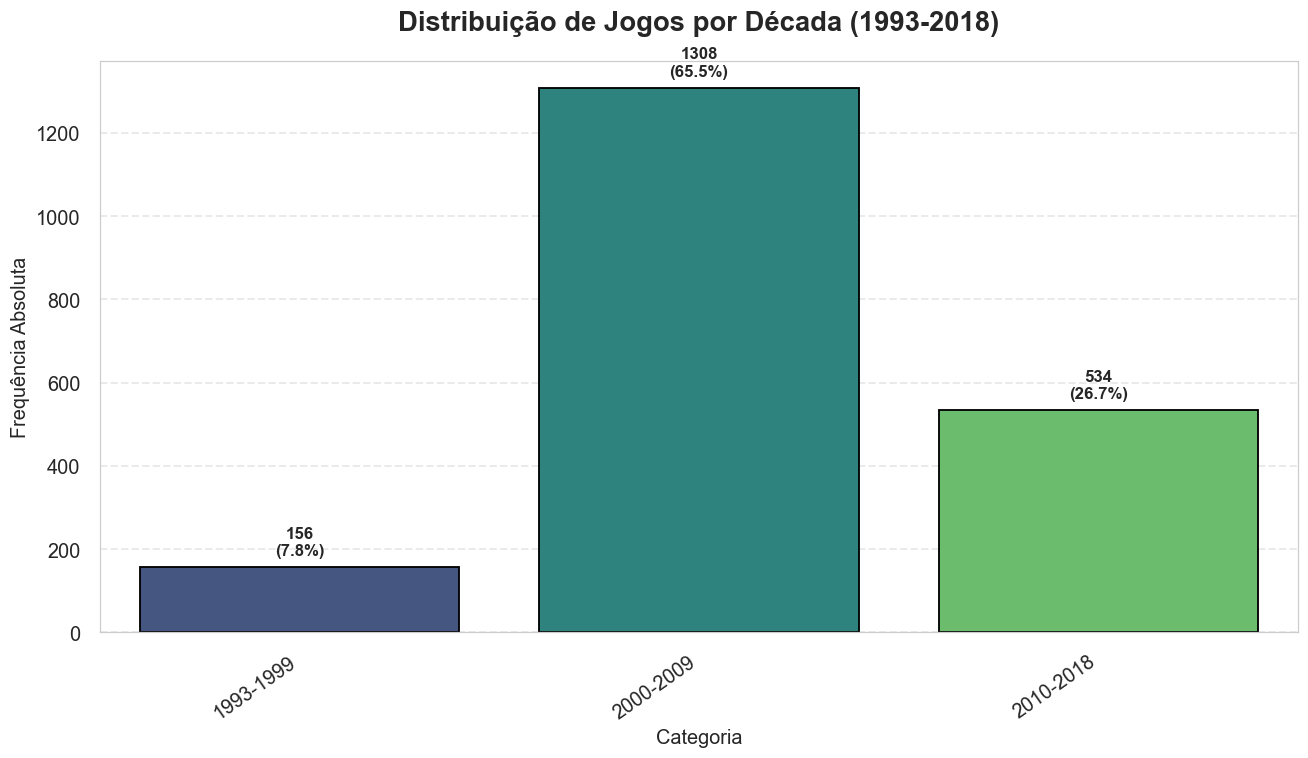

In [21]:
# Gráfico 1: Por década
plotar_histograma(
    df=df_clean,
    nome_coluna='year',
    bins=bins_decada,
    labels=labels_decada,
    titulo='Distribuição de Jogos por Década (1993-2018)',
    mostrar_percentual=True,
    palette='viridis'
)

#### **4.2.2. Distribuição Ano a Ano (Detalhada)**

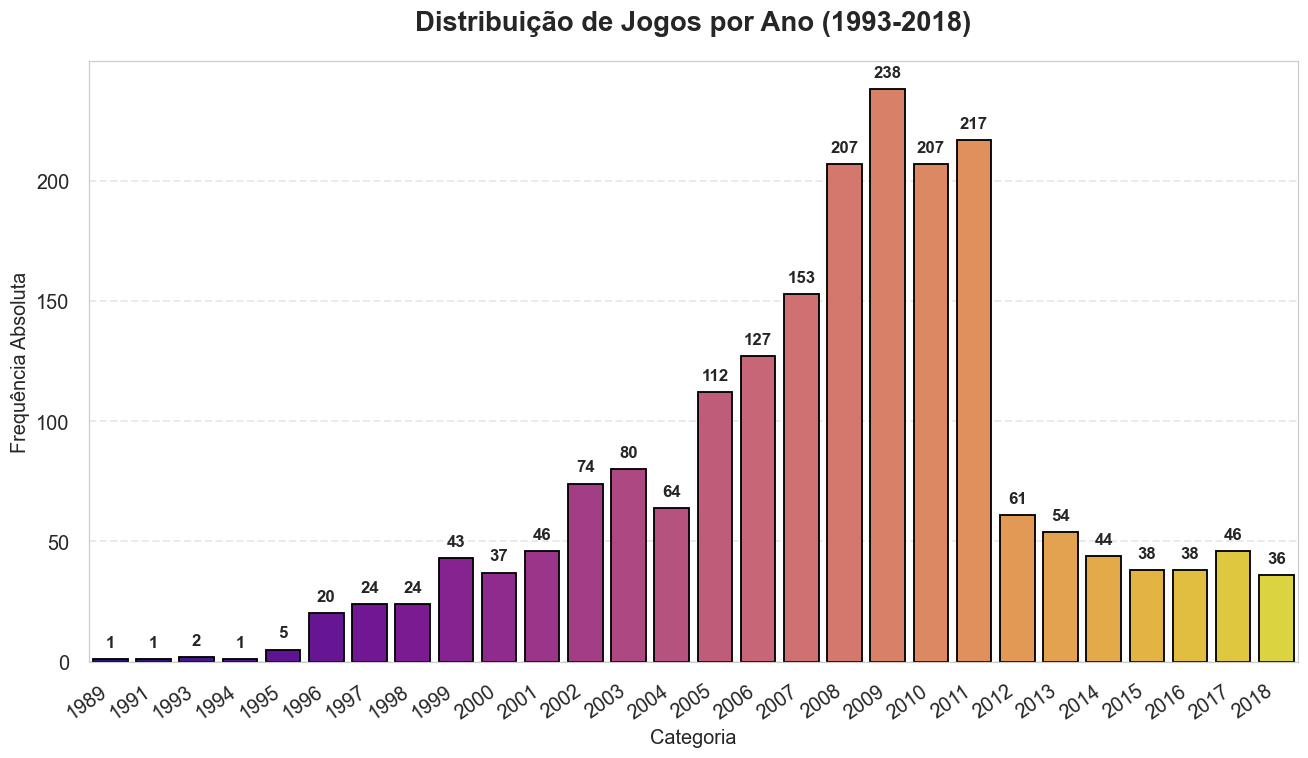

In [23]:
# Preparação para gráfico ano a ano
anos_unicos = sorted(df_clean['year'].unique())
bins_ano = [ano - 0.5 for ano in anos_unicos] + [anos_unicos[-1] + 0.5]
labels_ano = [str(int(ano)) for ano in anos_unicos]

# Gráfico 2: Ano a ano
plotar_histograma(
    df=df_clean,
    nome_coluna='year',
    bins=bins_ano,
    labels=labels_ano,
    titulo='Distribuição de Jogos por Ano (1993-2018)',
    mostrar_percentual=False,  # Muitos anos = poluído com %
    palette='plasma',
)

### **4.3. Medidas Descritivas Completas**

In [24]:
gerar_estatisticas_descritivas_md(df_clean, 'year')


📊 MEDIDAS DESCRITIVAS - YEAR

Contagem:              2000
Média:                 2007.84
Desvio Padrão:         4.71
Variância:             22.15
Mínimo:                1989.00
1º Quartil (Q1):       2005.00
Mediana (Q2):          2008.00
3º Quartil (Q3):       2011.00
Máximo:                2018.00
Moda:                  2009.00
Assimetria (Skew):     -0.35
Curtose (Kurt):        0.27




### **4.4. Análise de Distribuição - Boxplot**

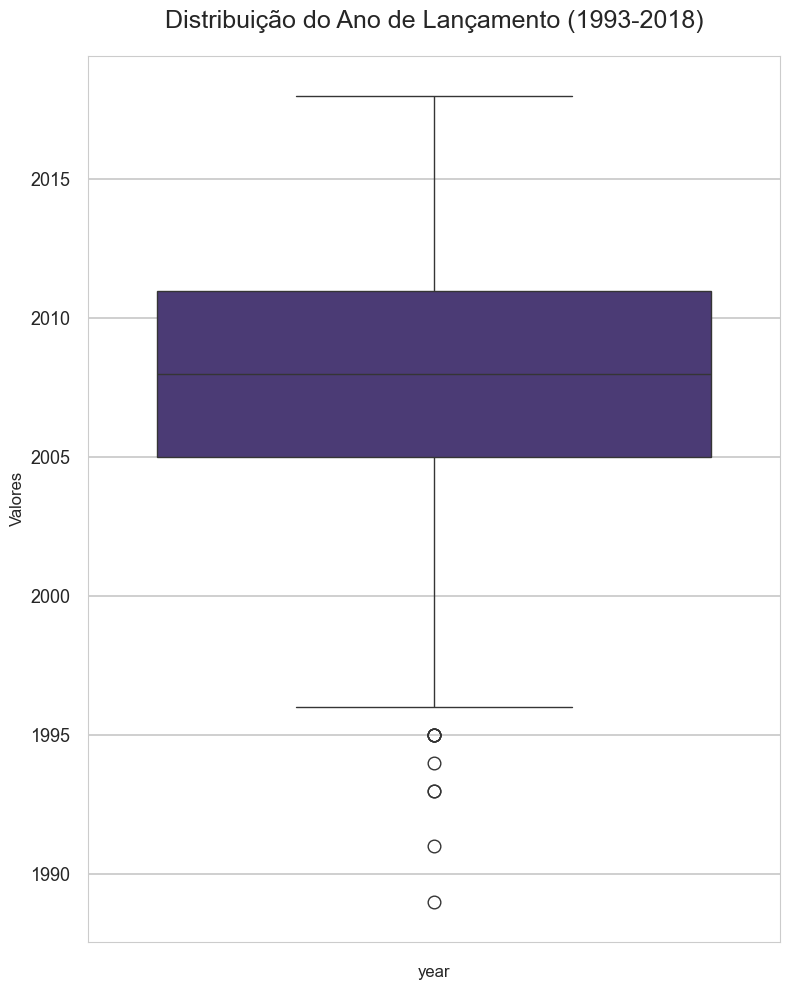

In [25]:
gerar_boxplot_md(
    df=df_clean,
    nome_coluna='year',
    titulo='Distribuição do Ano de Lançamento (1993-2018)',
    nome_arquivo='boxplot_year.png'
)

---

#### **Interpretação dos Resultados**

A análise descritiva da variável `year` revela padrões importantes sobre a evolução temporal do mercado de videogames:

- **Concentração temporal:** A mediana de **2008** indica que metade dos jogos mais vendidos do dataset foram lançados após esse ano, evidenciando o forte crescimento da indústria na década de 2000. A proximidade entre média (2007.84) e mediana (2008) sugere uma distribuição relativamente simétrica, reforçando a robustez desse padrão.

- **Era de ouro do mercado:** O intervalo interquartil (Q1=2005, Q3=2011) concentra 50% dos jogos mais vendidos em apenas 6 anos, período que coincide com o auge da geração HD (Xbox 360, PlayStation 3, Wii). A moda em **2009** reforça esse período como o pico de lançamentos de sucessos comerciais, consolidando a década de 2000 como a mais prolífica.

- **Assimetria negativa leve:** O coeficiente de assimetria de **-0.35** indica uma discreta cauda à esquerda, sugerindo maior concentração de jogos nos anos mais recentes (2005-2018), com presença menor mas relevante de títulos antigos. Isso reflete o amadurecimento da indústria e a maior capacidade de rastreamento de vendas nas últimas décadas.

- **Outliers históricos:** O boxplot identifica **5 outliers** de jogos lançados entre 1989 e 1993, incluindo clássicos que mantiveram vendas contínuas através de re-lançamentos, coleções especiais e distribuição digital. Esses títulos representam franquias atemporais que transcenderam suas gerações originais (ex: Super Mario, Pokémon, Tetris).

- **Baixa dispersão:** O desvio padrão de apenas **4.71 anos** e a curtose próxima de zero (0.27) indicam uma distribuição concentrada e equilibrada, confirmando que o dataset captura predominantemente jogos da "era moderna" da indústria (pós-2000), garantindo relevância e comparabilidade nas análises subsequentes.

- **Implicações para regressão:** A concentração de dados nos últimos 15 anos do período (2005-2018) sugere que os modelos de regressão capturarão principalmente padrões do mercado contemporâneo, onde críticas especializadas e plataformas digitais (Metacritic, IGN) já estavam consolidadas, aumentando a confiabilidade da relação entre `critic_score` e `total_sales`.

---